# 02 - Exploratory Data Analysis (EDA)
## Workplace Safety Data Analysis

In [2]:
import sys

print(sys.executable)

/opt/anaconda3/envs/myenv/bin/python


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
pd.set_option('display.max_columns', None)

df = pd.read_csv('data/cleaned/workplace_safety_dataset_cleaned.csv')
print(df.shape)
df.head()

(721, 17)


,employee_id,age,gender,department,job_role,years_experience,shift,accident_date,accident_type,severity,lost_days,ppe_used,training_completed,fatigue_level,root_cause,city,overtime_hours
0,1271,60,FEMALE,Operations,Operator,19.5,day,2023-04-13,Cut,Moderate,2,Yes,Yes,8.0,Fatigue,Bogotá,11.0
1,1131,39,FEMALE,Quality,Operator,1.4,day,2024-10-25,Ergonomic,Moderate,8,Yes,Yes,3.0,Human Error,Barranquilla,8.6
2,1055,20,MALE,Production,Operator,21.5,day,2025-05-25,Fall,Moderate,6,No,Unknown,10.0,Fatigue,Bogotá,11.8
3,1053,19,MALE,Warehouse,Operator,17.1,night,2025-02-15,Slip,Minor,7,Yes,No,4.0,Human Error,Cali,3.5
4,1002,23,FEMALE,Production,Coordinator,5.2,day,2024-07-15,Fall,Moderate,0,No,Yes,8.0,Fatigue,Cali,3.6


## Resultado del proceso de limpieza

El dataset original contenía aproximadamente 775 registros.

Después de aplicar las actividades de limpieza y validación de calidad de datos, el conjunto final quedó conformado por 721 registros y 17 variables.

Las actividades realizadas incluyeron:

- Tratamiento de valores nulos
- Eliminación de registros duplicados
- Estandarización de variables categóricas
- Corrección de inconsistencias
- Validación de reglas de negocio
- Tratamiento de valores atípicos

El dataset resultante fue considerado apto para el análisis exploratorio.

## Entender el dataset

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 721 entries, 0 to 720
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   employee_id         721 non-null    int64  
 1   age                 721 non-null    int64  
 2   gender              721 non-null    object 
 3   department          721 non-null    object 
 4   job_role            721 non-null    object 
 5   years_experience    721 non-null    float64
 6   shift               721 non-null    object 
 7   accident_date       721 non-null    object 
 8   accident_type       721 non-null    object 
 9   severity            721 non-null    object 
 10  lost_days           721 non-null    int64  
 11  ppe_used            721 non-null    object 
 12  training_completed  721 non-null    object 
 13  fatigue_level       721 non-null    float64
 14  root_cause          721 non-null    object 
 15  city                721 non-null    object 
 16  overtime

In [3]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
employee_id,721.0,NaN,NaN,NaN,1154.255201,85.849942,1001.0,1079.0,1156.0,1230.0,1299.0
age,721.0,NaN,NaN,NaN,38.736477,12.611389,18.0,28.0,38.0,51.0,60.0
gender,721,2,FEMALE,368,NaN,NaN,NaN,NaN,NaN,NaN,NaN
department,721,6,Quality,138,NaN,NaN,NaN,NaN,NaN,NaN,NaN
job_role,721,5,Coordinator,157,NaN,NaN,NaN,NaN,NaN,NaN,NaN
years_experience,721.0,NaN,NaN,NaN,13.042857,7.16446,0.0,6.8,13.3,19.1,25.0
shift,721,2,night,365,NaN,NaN,NaN,NaN,NaN,NaN,NaN
accident_date,721,495,2025-05-30,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
accident_type,721,6,Struck By Object,124,NaN,NaN,NaN,NaN,NaN,NaN,NaN
severity,721,3,Minor,403,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## KPIs Principales

In [19]:
total_accidents=len(df)
print("El total de accidentes fue:",total_accidents)
total_lost_days=df['lost_days'].sum()
print("El total de días perdidos fue:",total_lost_days)
avg_lost_days=df['lost_days'].mean()
print("El promedio de días perdidos fue:",avg_lost_days)
avg_lost_days = df['lost_days'].mean()
print("El promedio de días perdidos fue:", avg_lost_days)


El total de accidentes fue: 721
El total de días perdidos fue: 5794
El promedio de días perdidos fue: 8.03606102635229
El promedio de días perdidos fue: 8.03606102635229


In [21]:
df['severity'].value_counts()

severity
Minor       403
Moderate    223
Severe       95
Name: count, dtype: int64

In [22]:
df['department'].value_counts()

department
Quality        138
Maintenance    129
Production     126
Logistics      126
Warehouse      106
Operations      96
Name: count, dtype: int64

In [23]:
df['root_cause'].value_counts()

root_cause
Fatigue               150
PPE Non-Compliance    148
Lack of Training      145
Unsafe Condition      145
Human Error           133
Name: count, dtype: int64

## Accidentes por Departamento

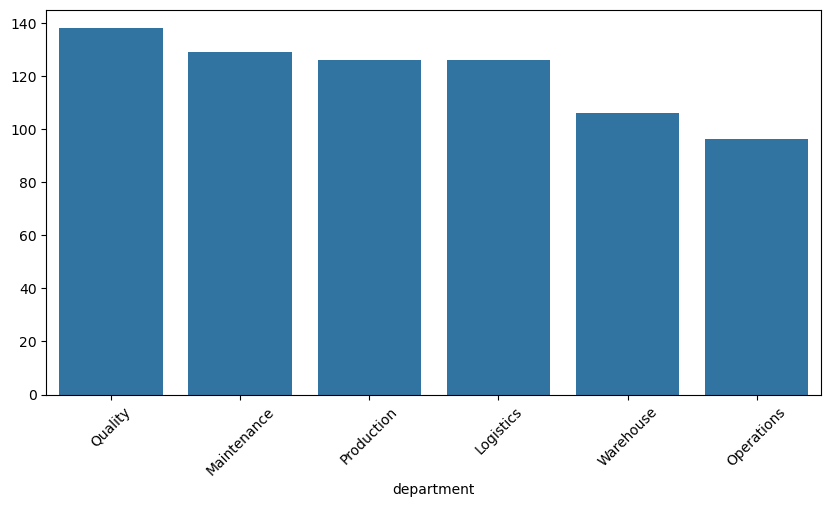

In [31]:
department_accidents=df['department'].value_counts().sort_values(ascending=False)
plt.figure(figsize=(10,5))
sns.barplot(x=department_accidents.index,y=department_accidents.values)
plt.xticks(rotation=45)
plt.savefig('images/accidentes_departamento.png', bbox_inches='tight', dpi=300)
plt.show()

## Accidentes por Ciudad

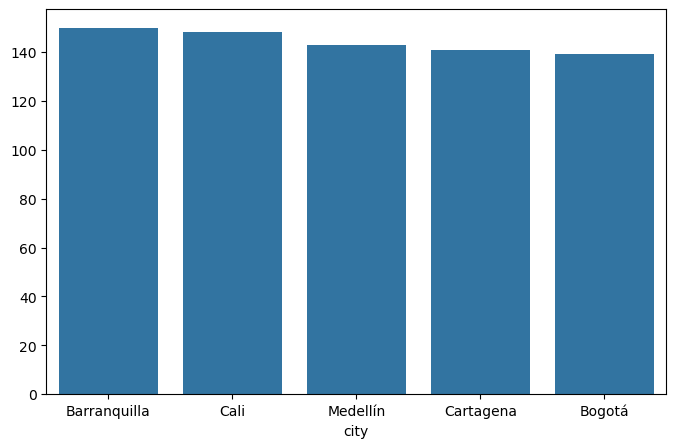

In [7]:
city_accidents=df['city'].value_counts()
plt.figure(figsize=(8,5))
sns.barplot(x=city_accidents.index,y=city_accidents.values)
plt.show()

## Distribución de Severidad

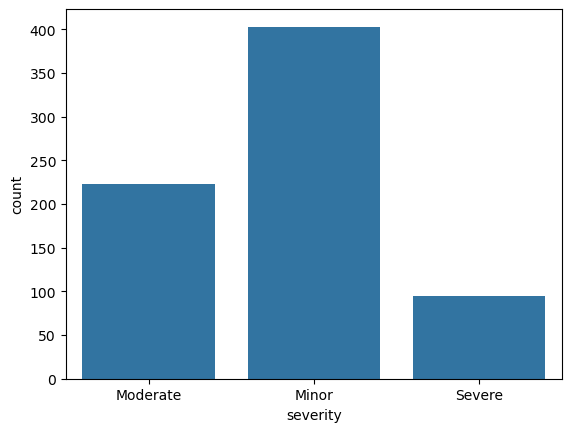

In [33]:
sns.countplot(data=df,x='severity')
plt.savefig('images/severidad.png', bbox_inches='tight', dpi=300)
plt.show()

## Accidentes por Turno

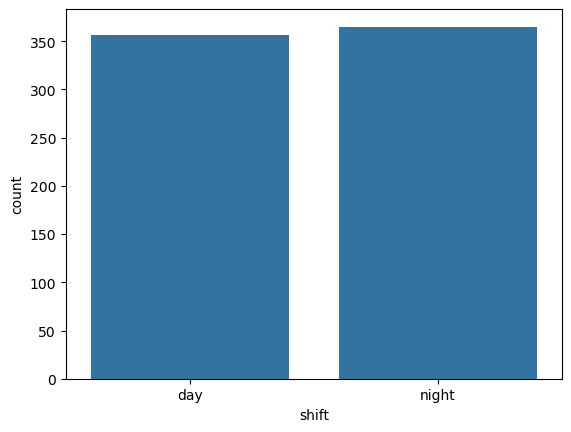

In [9]:
sns.countplot(data=df,x='shift')
plt.show()

## Principales Causas Raíz

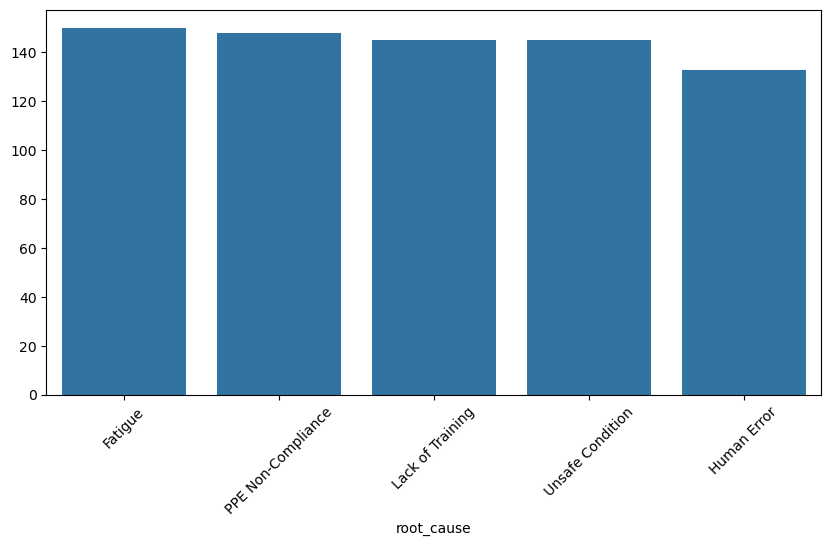

In [32]:
root_causes=df['root_cause'].value_counts()
plt.figure(figsize=(10,5))
sns.barplot(x=root_causes.index,y=root_causes.values)
plt.xticks(rotation=45)
plt.savefig('images/causa_raiz.png', bbox_inches='tight', dpi=300)
plt.show()

## Fatiga vs Días Perdidos

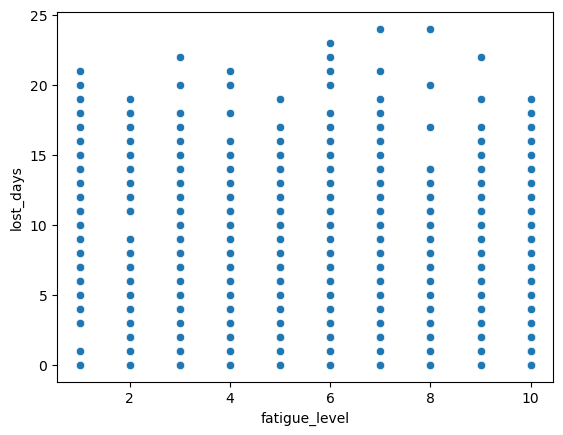

In [11]:
sns.scatterplot(data=df,x='fatigue_level',y='lost_days')
plt.show()

## Horas Extra vs Días Perdidos

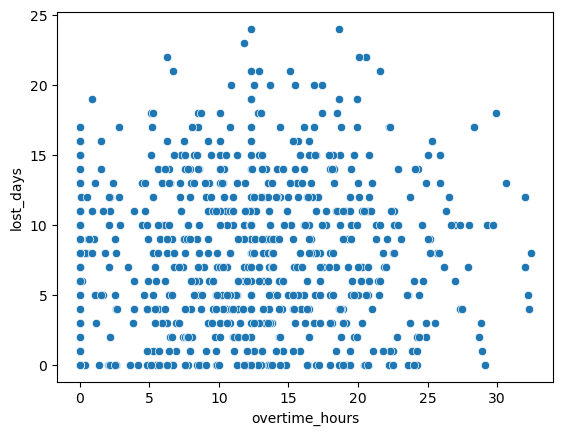

In [12]:
sns.scatterplot(data=df,x='overtime_hours',y='lost_days')
plt.show()

## Tendencia Mensual

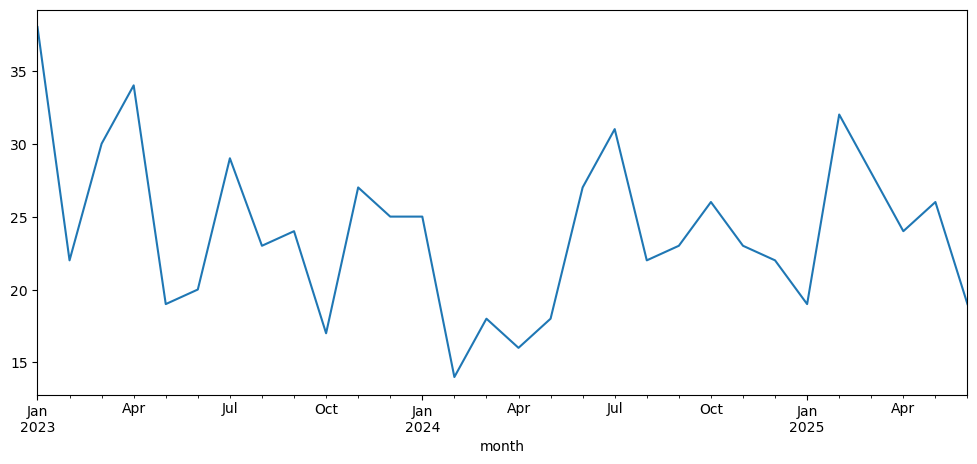

In [34]:
df['accident_date']=pd.to_datetime(df['accident_date'])
df['month']=df['accident_date'].dt.to_period('M')
monthly_trend=df.groupby('month').size()
monthly_trend.plot(figsize=(12,5))
plt.savefig('images/tendencia_mensual.png', bbox_inches='tight', dpi=300)
plt.show()

## Matriz de Correlación

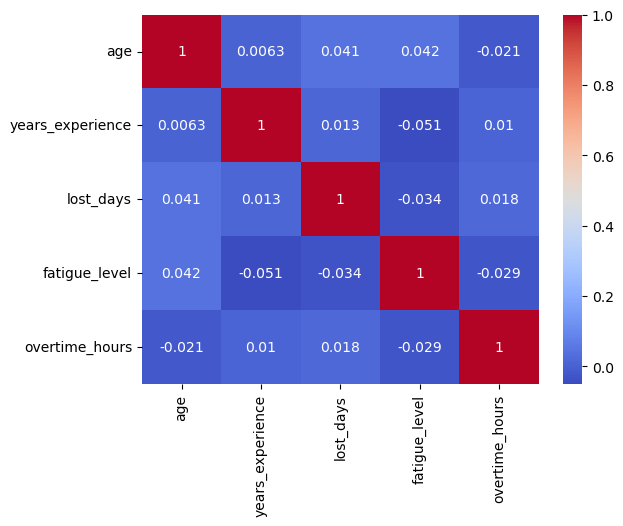

In [35]:
corr=df[['age','years_experience','lost_days','fatigue_level','overtime_hours']].corr()
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.savefig('images/correlacion.png', bbox_inches='tight', dpi=300)
plt.show()

# Conclusión Ejecutiva
**Resumen General**

El presente análisis exploratorio se desarrolló sobre un conjunto de 721 registros de accidentes laborales, previamente sometidos a un proceso de limpieza y validación de calidad de datos. El objetivo fue identificar patrones de accidentalidad, factores de riesgo y oportunidades de mejora para fortalecer la gestión de Seguridad y Salud en el Trabajo (SST).

Los resultados evidencian que los accidentes analizados generaron un total de 5.794 días perdidos, con un promedio de 8 días por evento, lo que refleja un impacto significativo sobre la productividad, la continuidad operacional y los costos asociados al ausentismo laboral.

**Principales Hallazgos**

La distribución de la severidad muestra que el 55,9% de los accidentes fueron clasificados como menores, mientras que el 30,9% correspondieron a eventos moderados y el 13,2% a eventos severos. Aunque la mayoría de los casos presentan consecuencias limitadas, la presencia de 95 accidentes severos representa una exposición relevante al riesgo que requiere atención prioritaria.

El análisis por área permitió identificar que los departamentos de Quality, Maintenance y Production concentran la mayor cantidad de accidentes reportados. Este comportamiento sugiere la necesidad de focalizar esfuerzos preventivos en los procesos, tareas y condiciones de trabajo presentes en estas áreas.

Respecto a las causas raíz, la fatiga se posiciona como el factor más recurrente, seguida por el incumplimiento en el uso de elementos de protección personal (EPP), la falta de capacitación y las condiciones inseguras. La distribución relativamente homogénea de estas causas indica que la accidentalidad responde a múltiples factores organizacionales y comportamentales, más que a una única condición de riesgo.

**Implicaciones para la Gestión SST**

Los hallazgos sugieren que existe una oportunidad significativa para reducir la frecuencia y severidad de los accidentes mediante intervenciones preventivas orientadas a:

Gestión de la fatiga y control de jornadas prolongadas.
Fortalecimiento de los programas de formación y entrenamiento.
Incremento de las estrategias de observación y control del uso adecuado de EPP.
Identificación y corrección oportuna de condiciones inseguras.
Priorización de acciones de mejora en las áreas con mayor concentración de eventos.

**Conclusión Estratégica**

Desde una perspectiva de gestión, los resultados evidencian que la organización cuenta con oportunidades claras para fortalecer su cultura de seguridad y avanzar hacia un enfoque más preventivo. La información obtenida permite orientar la toma de decisiones basada en datos, priorizar recursos de intervención y establecer indicadores de seguimiento enfocados en los principales factores de riesgo identificados.

La integración de analítica de datos en los procesos de SST demuestra ser una herramienta valiosa para transformar registros históricos de accidentalidad en información accionable, facilitando la implementación de estrategias que contribuyan a la reducción de incidentes, la protección de los trabajadores y la mejora del desempeño organizacional.